In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio as rio
import matplotlib as mpl
import matplotlib.pyplot as plt
from pyproj import Transformer
from shapely.geometry import LineString

data_dir = '../data_in/'
data_out_dir = '../data_out/'

In [2]:
def create_scanline(x, y, angle_deg, distance):
    """
    Create a scanline geometry (LineString) based on a given location, angle, and distance.
    :param lon: longitude of the center point (in WGS84)
    :param lat: latitude of the center point (in WGS84)
    :param angle_deg: angle of the scanline in degrees (0° = north, 90° = east)
    :param distance: distance from the center point to the start and end points of the scanline (in meters)
    :param target_crs: target coordinate reference system for the output geometry (default: UTM 32N, EPSG:32632)
    :return: line geometry as a GeoDataFrame with the specified CRS
    """
    angle = np.radians(angle_deg)
    dx = np.sin(angle) * distance
    dy = np.cos(angle) * distance

    # calculate start and end points of the scanline
    start_x, start_y = x - dx, y - dy
    end_x, end_y = x + dx, y + dy

    # create LineString geometry for the scanline
    line = LineString([(start_x, start_y), (x, y), (end_x, end_y)])
    gdf_line = gpd.GeoDataFrame(index=[0], geometry=[line])
    gdf_line['angle_deg'] = angle_deg
    gdf_line.set_crs(target_crs, inplace=True)

    return gdf_line

## Script settings

In [3]:
target_crs="EPSG:32632"
transformer = Transformer.from_crs("EPSG:4326", target_crs, always_xy=True)

# RHI settings
angles = [25, 80, 115]
distance = 2000

rhi_range = 100
rhi_zenith_bins = 168

## Determine RHI scan lines

In [4]:
# get outline of Hintereisferner (HEF)
rgi = gpd.read_file('../data_in/Glacier_Outlines_v370_2030_smoothed.geojson')
rgi_hef = rgi.loc[rgi['rgi_id'] == 'RGI60-11.00897'].to_crs(target_crs)

In [5]:
# get lidar position from location file
loc_file = data_dir + f'H3_Coords_w_cells.csv'
df_locs = pd.read_csv(loc_file)
df_locs = df_locs[df_locs["Type"]=="Lidar"]
df_locs

,cell_id,topo,Original Name,New Name,Type,UAV Takeoff,Lat,Lon,Alt,Comment,Alt_DEM_2022
7,35704,2798.971191,Lidar,Lidar,Lidar,NaN,46.801632,10.771678,2720.0,from Streamline GPS,2726.23


In [6]:
# create scanline geometry for the RHI
lon, lat = df_locs.iloc[0]['Lon'], df_locs.iloc[0]['Lat']
lidar_x, lidar_y = transformer.transform(lon, lat)

lines = []
for angle in angles:
    lines.append(create_scanline(lidar_x, lidar_y, angle, distance))

gdf_lines = gpd.GeoDataFrame(pd.concat(lines, ignore_index=True))
gdf_lines

,geometry,angle_deg
0,"LINESTRING (634343.979 5182831.881, 635189.216...",25
1,"LINESTRING (633219.6 5184297.201, 635189.216 5...",80
2,"LINESTRING (633376.6 5185489.734, 635189.216 5...",115


## Get DEM point for scan lines

In [7]:
def get_elevation_along_line(line, zenith_bins, target_crs):

    # create points along line according to number of zenith bins
    s = np.linspace(0, line.length, zenith_bins)
    points = [line.interpolate(dist) for dist in s]
    coords = [(p.x, p.y) for p in points]

    # sample DEM values on given DEMs
    with rio.open(dem_paths[0]) as dem_full:
        full_vals = np.array([v[0] for v in dem_full.sample(coords)])

    with rio.open(dem_paths[1]) as dem_sml:
        sml_vals = np.array([v[0] for v in dem_sml.sample(coords)])
        nodata = dem_sml.nodata

    # discard involid samples
    sml_invalid = (
            np.isnan(sml_vals) |
            (sml_vals == nodata) |
            (sml_vals <= 0)
    )

    # merge samples from DEMs
    dem_merged = full_vals.copy()
    dem_merged[~sml_invalid] = sml_vals[~sml_invalid]

    gdf = gpd.GeoDataFrame(geometry=points, crs=target_crs)
    gdf['elevation'] = dem_merged
    return gdf

In [8]:
dem_path = r"/Users/geoalxx/Python/glacier_space/qgis/hef_dem/copdem.tif"  # complete but 30 m res DEM
dem_path_sml = r'/Users/geoalxx/Python/glacier_space/qgis/DEM2022/PGO_dem_2022_geoid.tif'  # high res, recent but not complete DEM
dem_paths = [dem_path, dem_path_sml]

print(f'Target CRS:\n{target_crs}')
print('CRS of given DEMs:')
for p in dem_paths:
    with rio.open(p) as dem:
        print(dem.crs)

Target CRS:
EPSG:32632
CRS of given DEMs:
EPSG:32632
EPSG:32632


In [9]:
# get raster for map background
with rio.open(dem_path) as src:
    dem_raster = src.read(1)
    bounds = src.bounds

extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]

In [10]:
# get points along RHI scan line for all angles
rhi_elevations = {}
for idx, row in gdf_lines.to_crs(target_crs).iterrows():
    rhi_elevations[row.angle_deg] = get_elevation_along_line(row.geometry, rhi_zenith_bins, target_crs)

## Plot results

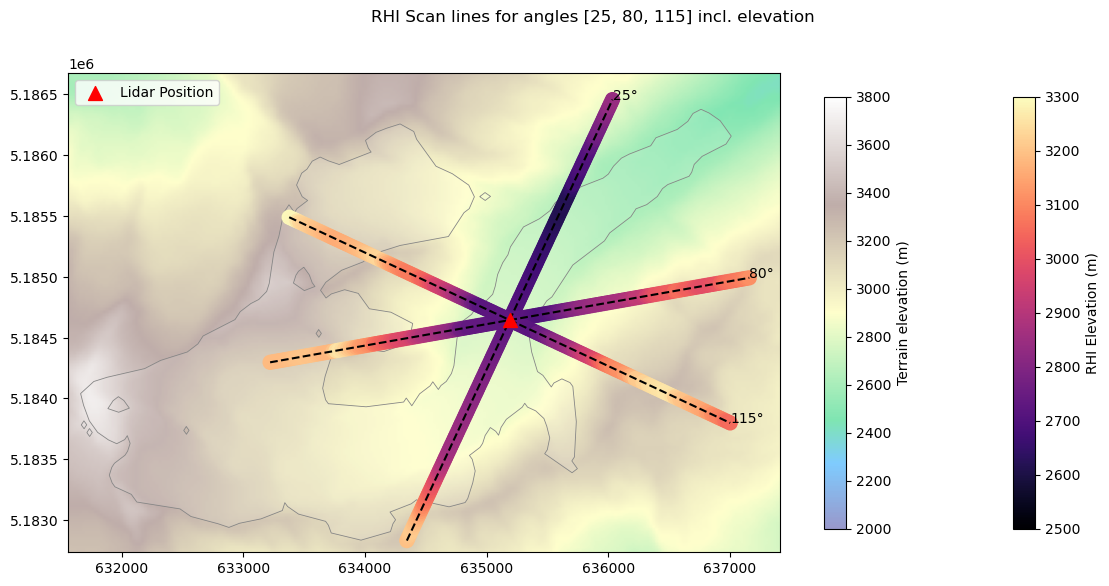

In [11]:
fig,ax = plt.subplots(1,1,figsize=(12,6))

# HEF outline
rgi_hef.boundary.plot(ax=ax, lw=.6, color='grey', zorder=-10)
rgi_hef.plot(ax=ax, color='white',alpha=.1)

# RHI lines
gdf_lines.plot(ax=ax, color='black', ls='--')
for idx, row in gdf_lines.iterrows():
    pt = row.geometry.interpolate(1, normalized=True)  # midpoint on line
    ax.text(pt.x, pt.y, f"{row['angle_deg']}°", fontsize=10)

# Elevation points
cmap, min, max = 'magma',2500,3300
for k in rhi_elevations.keys():
    rhi_elevations[k].plot(ax=ax, column='elevation', vmin=min, vmax=max, cmap=cmap, s=100)
sm = mpl.cm.ScalarMappable(cmap=cmap,norm=mpl.colors.Normalize(vmin=min, vmax=max))
fig.colorbar(sm, ax=ax, shrink=.8, label='RHI Elevation (m)')

# Lidar position
ax.scatter(lidar_x, lidar_y, color='red', marker='^', label='Lidar Position', s=100, zorder=10)
ax.legend()

# background DEM
im = ax.imshow(dem_raster, cmap="terrain", alpha=.5, extent=extent, origin="upper", vmin=2000, vmax=3800, zorder=-20)
fig.colorbar(im, ax=ax, shrink=.8, label=f'Terrain elevation (m)')

# limit DEM extent to HEF
ax.set_xlim(rgi_hef.bounds.minx.min() - 100, rgi_hef.bounds.maxx.max() + 400)
ax.set_ylim(rgi_hef.bounds.miny.min() - 100, rgi_hef.bounds.maxy.max() + 300)

plt.suptitle(f'RHI Scan lines for angles {angles} incl. elevation ')
plt.tight_layout()
plt.show()

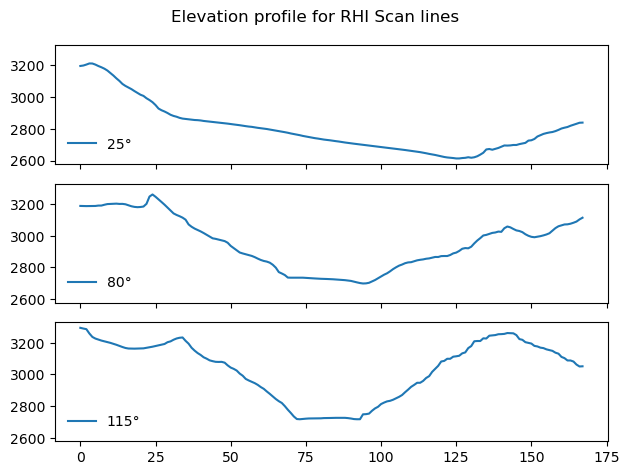

In [12]:
fig,axs = plt.subplots(nrows=len(rhi_elevations), ncols=1, sharex=True, sharey=True)

for i,k in enumerate(rhi_elevations.keys()):
    vals = rhi_elevations[k]['elevation']
    axs[i].plot(vals, label=f'{k}°')
    axs[i].legend(loc='lower left', frameon=False)

plt.suptitle('Elevation profile for RHI Scan lines')
plt.tight_layout()
plt.show()

## Save outputs